## Air Traffic Imbalances: Identifying Airports That Are Busier Than Expected

**Team members**: [David Friedenberg](https://github.com/), [Agniva Dasgupta](https://github.com/), [Charuhas Shiveshwarkar](https://github.com/), [Ivan Caro Terrazas](https://github.com/icaromx), [Ahmad Shamloumehr](https://github.com/)

This notebook uses the TSA hourly passenger throughput dataset to build a machine learning workflow for short-term load forecasting.

## Workflow
1. Load and preprocess the dataset

## Pipeline overview

Raw data → Preprocessing → Train/Test Split → Model Training → Evaluation

## Models compared
- SARIMA
- Harmonic Ressonance

The goal is not only to obtain strong predictive performance, but also to keep the pipeline clear, modular, and reproducible.

## Imports

In [1]:
# Import packages
import plotly.graph_objects as go
import pandas as pd
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import pmdarima as pm
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

#Importing custom methods from src/ directory
from src.preprocessing import load_data

## Data loading and preprocessing

The TSA dataset is loaded and column names are renamed to an easier way to parse them.

In [2]:
df = load_data("data/tsa-throughput-data-complete.csv")
print("Raw shape:", df.shape)
display(df.head())
display(df.info())

Raw shape: (11054590, 10)


,datetime,airport_code,airport_name,city,state,checkpoint,total_passenger_throughput,date,month,week
0,2022-01-01,ANC,Ted Stevens Anchorage International,Anchorage,AK,South Checkpoint,62,2022-01-01,1,52
1,2022-01-01,ATL,Hartsfield Atlanta International,Atlanta,GA,Main Checkpoint,17,2022-01-01,1,52
2,2022-01-01,BFL,"Meadows Field, Bakersfield",Bakersfield,CA,BFL01,0,2022-01-01,1,52
3,2022-01-01,BIH,Eastern Sierra Regional Airport,Bishop,CA,Checkpoint 1,0,2022-01-01,1,52
4,2022-01-01,BQN,Rafael Hernandez,Aguadilla,PR,Rafael Hernandez Air,211,2022-01-01,1,52


<class 'pandas.DataFrame'>
RangeIndex: 11054590 entries, 0 to 11054589
Data columns (total 10 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   datetime                    datetime64[us]
 1   airport_code                str           
 2   airport_name                str           
 3   city                        str           
 4   state                       str           
 5   checkpoint                  str           
 6   total_passenger_throughput  int64         
 7   date                        object        
 8   month                       int32         
 9   week                        int64         
dtypes: datetime64[us](1), int32(1), int64(2), object(1), str(5)
memory usage: 1.3+ GB


None

# Exploratory Data Analysis

In [4]:
from src.eda import (
    plot_hourly_by_airport_checkpoint,
    plot_daily_by_airport_checkpoint
)

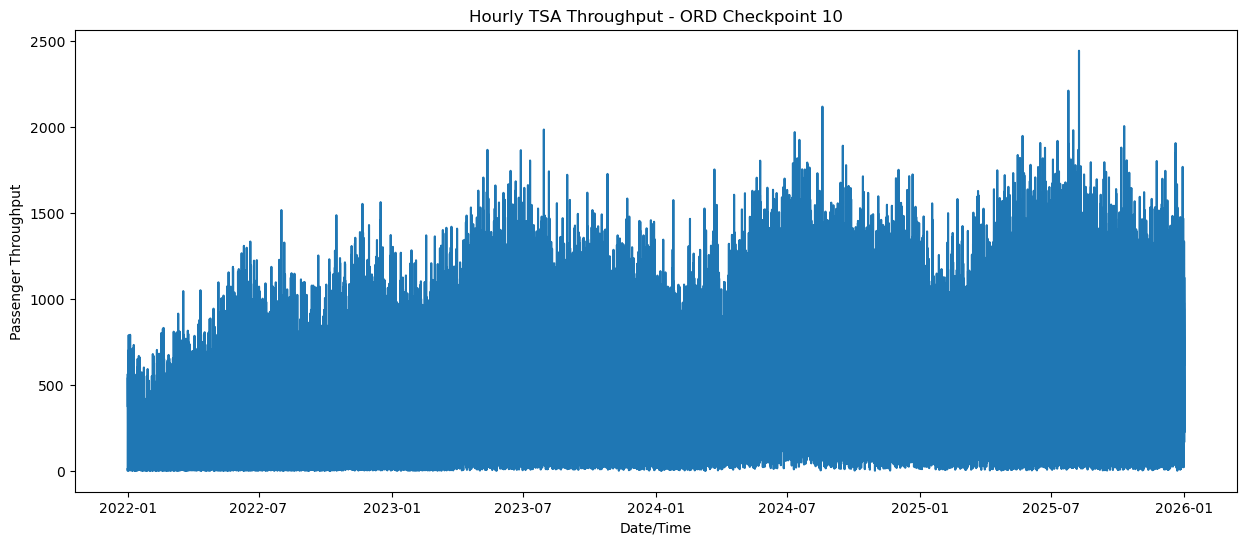

In [5]:
plot_hourly_by_airport_checkpoint(df, checkpoint='10', airport='ORD')

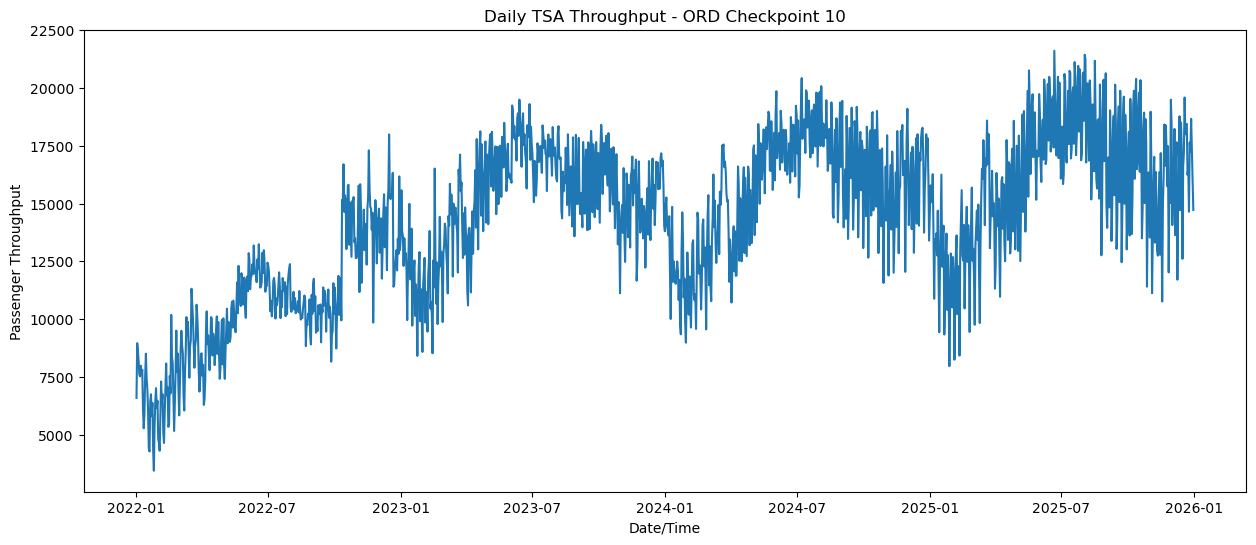

In [6]:
plot_daily_by_airport_checkpoint(df, checkpoint='10', airport='ORD')